# 3G - Ciclo de vida do Nino 3.4 em relacao ao DHW

**Pergunta especifica.** Como o calor acumulado evolui durante o evento, qual DHW separa melhor intensidade/duracao e como comparar P90 e P95 de forma consistente?

**Objetivo.** Tratar DHW como severidade acumulada: comparar eventos, picos P90 e cauda P95 sem confundir DHW com criterio de nascimento do El Nino.

**Justificativa.** DHW normalmente pica depois da SSTA. Portanto, ele e melhor como metrica de carga termica e severidade integrada do que como precursor longo.

**Metodologia.** Alinha SSTA e DHW ao pico, calcula metricas por evento para `dhw_12w` e `dhw_26w_p90`, estima escalonamento com intensidade/duracao e mantem mapa longitude x tempo como aproximacao visual com caveat.

**Saidas.** `phase3G_composto_ssta_dhw.csv`, `phase3G_eventos_dhw.csv`, `phase3G_escalonamento.csv`, `phase3G_estado_atual.csv`, figuras e mapa DHW-lon.


[tabela] data\processed\parquet\statistics\phase3G_composto_ssta_dhw.csv
picos compostos do DHW em relacao ao pico da SSTA: {'dhw_12w': 9, 'dhw_26w_p90': 12}
[figura] data\processed\figures\fase3\phase3G_composto_ssta_dhw.png


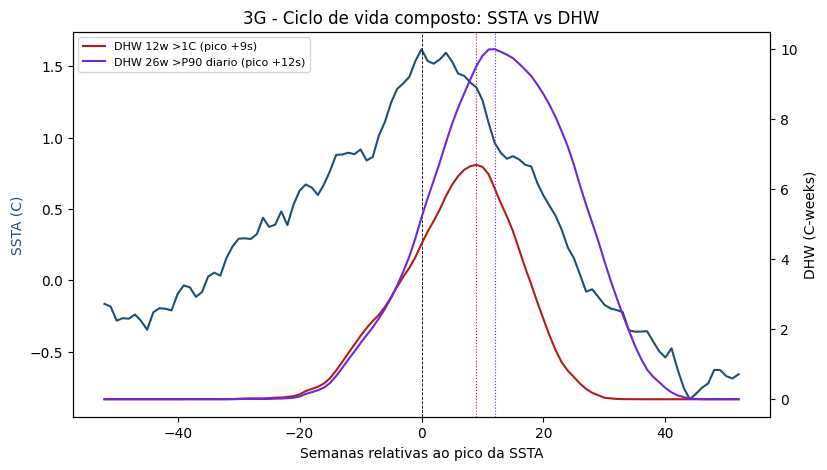

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
sys.path.insert(0, '.')
import fase3_utils as u

weekly = pd.read_csv(u.FEAT / 'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
ev = u.load_events()
ssta = weekly['nino34_ssta']
DHW_METRICS = {'dhw_12w': 'DHW 12w >1C', 'dhw_26w_p90': 'DHW 26w >P90 diario'}

# Composto duplo alinhado ao pico
lags = list(range(-52, 53))
def composite(series):
    mats = []
    for _, e in ev.iterrows():
        idx = series.index.get_indexer([e.peak_time], method='nearest')[0]
        seg = series.iloc[max(0, idx-52): idx+53]
        rel = ((seg.index - series.index[idx]).days / 7).round().astype(int)
        mats.append(pd.Series(seg.values, index=rel))
    return pd.DataFrame(mats).reindex(columns=lags).mean()
comp = pd.DataFrame({'ssta': composite(ssta)})
for metric in DHW_METRICS:
    comp[metric] = composite(weekly[metric])
u.save_table(comp.rename_axis('semana_rel_pico_ssta'), 'phase3G_composto_ssta_dhw.csv')
lag_picos = {m: int(comp[m].idxmax()) for m in DHW_METRICS}
print('picos compostos do DHW em relacao ao pico da SSTA:', lag_picos)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(comp.index, comp['ssta'], color='#1f4e79', label='SSTA (C)')
ax1.set_ylabel('SSTA (C)', color='#1f4e79'); ax1.axvline(0, color='k', ls='--', lw=0.6)
ax2 = ax1.twinx()
colors = {'dhw_12w':'#b71c1c', 'dhw_26w_p90':'#6d28d9'}
for metric, label in DHW_METRICS.items():
    ax2.plot(comp.index, comp[metric], color=colors[metric], label=f'{label} (pico {lag_picos[metric]:+d}s)')
    ax2.axvline(lag_picos[metric], color=colors[metric], ls=':', lw=0.8)
ax2.set_ylabel('DHW (C-weeks)')
ax1.set_xlabel('Semanas relativas ao pico da SSTA')
ax1.set_title('3G - Ciclo de vida composto: SSTA vs DHW')
ax2.legend(fontsize=8, loc='upper left')
u.save_fig(fig, 'phase3G_composto_ssta_dhw.png')
plt.show()


In [2]:
# Metricas por evento: DHW nas fases nascimento/crescimento/pico/decaimento
rows = []
for _, e in ev.iterrows():
    onset, peak, end = e.event_start, e.peak_time, e.event_end
    meio = onset + (peak - onset) / 2
    row = {'event_id': e.event_id, 'classe': e.peak_class,
           'ssta_pico_c': round(e.peak_monthly_ssta_c, 3), 'duracao_meses': e.duration_months}
    for metric in DHW_METRICS:
        series = weekly[metric]
        seg = series.loc[onset:end]
        idx_pk_dhw = seg.idxmax() if seg.notna().any() else pd.NaT
        prefix = metric
        row.update({
            f'{prefix}_no_nascimento': round(float(series.asof(onset)), 2),
            f'{prefix}_meio_crescimento': round(float(series.asof(meio)), 2),
            f'{prefix}_no_pico_ssta': round(float(series.asof(peak)), 2),
            f'{prefix}_maximo': round(float(seg.max()), 2) if seg.notna().any() else np.nan,
            f'{prefix}_defasagem_pico_semanas': int(round((idx_pk_dhw - peak).days / 7)) if pd.notna(idx_pk_dhw) else np.nan,
            f'{prefix}_no_fim': round(float(series.asof(end)), 2),
        })
    rows.append(row)
met = pd.DataFrame(rows)
u.save_table(met, 'phase3G_eventos_dhw.csv', index=False)
met


[tabela] data\processed\parquet\statistics\phase3G_eventos_dhw.csv


,event_id,classe,ssta_pico_c,duracao_meses,dhw_12w_no_nascimento,dhw_12w_meio_crescimento,dhw_12w_no_pico_ssta,dhw_12w_maximo,dhw_12w_defasagem_pico_semanas,dhw_12w_no_fim,dhw_26w_p90_no_nascimento,dhw_26w_p90_meio_crescimento,dhw_26w_p90_no_pico_ssta,dhw_26w_p90_maximo,dhw_26w_p90_defasagem_pico_semanas,dhw_26w_p90_no_fim
0,el_nino_oisst_1982_1983,super_el_nino,2.213,11,0.0,1.19,10.47,14.19,6,4.49,0.0,0.96,11.33,22.24,11,18.02
1,el_nino_oisst_1986_1988,moderate_el_nino,1.223,16,0.0,0.45,0.46,2.95,11,0.47,0.0,0.20,0.44,2.59,19,2.53
2,el_nino_oisst_1991_1992,strong_el_nino,1.736,10,0.0,0.04,2.16,7.81,9,0.96,0.0,0.01,1.84,8.14,21,8.06
3,el_nino_oisst_1994_1995,weak_el_nino,1.192,5,0.0,0.00,0.03,1.07,6,1.07,0.0,0.00,0.01,0.73,5,0.73
4,el_nino_oisst_1997_1998,super_el_nino,2.166,11,0.0,4.30,12.28,13.80,10,8.67,0.0,3.77,16.19,25.75,11,22.52
5,el_nino_oisst_2002_2003,moderate_el_nino,1.250,8,0.0,0.00,0.35,3.27,10,2.96,0.0,0.00,0.19,2.73,11,2.73
6,el_nino_oisst_2004,weak_el_nino,0.681,5,0.0,0.00,0.00,0.00,-4,0.00,0.0,0.00,0.00,0.00,-4,0.00
7,el_nino_oisst_2006_2007,weak_el_nino,1.128,5,0.0,0.00,0.02,0.57,4,0.57,0.0,0.00,0.00,0.30,4,0.30
8,el_nino_oisst_2009_2010,strong_el_nino,1.719,10,0.0,0.00,2.13,7.47,8,4.21,0.0,0.00,1.80,8.41,17,8.41
9,el_nino_oisst_2014_2016,super_el_nino,2.448,19,0.0,0.03,15.50,19.09,9,14.54,0.0,0.00,18.97,33.99,15,33.28


[tabela] data\processed\parquet\statistics\phase3G_escalonamento.csv


[figura] data\processed\figures\fase3\phase3G_escalonamento.png


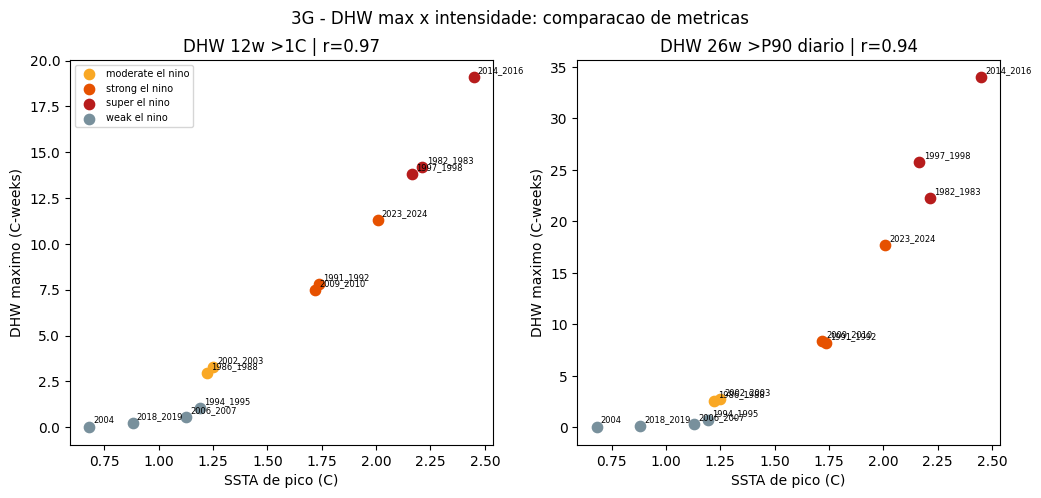

,metrica_dhw,relacao,r,n_eventos
0,dhw_12w,dhw_max x ssta_pico,0.975,12
1,dhw_12w,dhw_max x duracao,0.711,12
2,dhw_26w_p90,dhw_max x ssta_pico,0.939,12
3,dhw_26w_p90,dhw_max x duracao,0.690,12


In [3]:
# Escalonamento: DHW maximo x intensidade/duracao do evento
rows = []
for metric in DHW_METRICS:
    mm = met.dropna(subset=[f'{metric}_maximo'])
    r_int = float(np.corrcoef(mm[f'{metric}_maximo'], mm['ssta_pico_c'])[0,1])
    r_dur = float(np.corrcoef(mm[f'{metric}_maximo'], mm['duracao_meses'])[0,1])
    rows.extend([
        {'metrica_dhw': metric, 'relacao': 'dhw_max x ssta_pico', 'r': round(r_int,3), 'n_eventos': len(mm)},
        {'metrica_dhw': metric, 'relacao': 'dhw_max x duracao', 'r': round(r_dur,3), 'n_eventos': len(mm)},
    ])
esc = pd.DataFrame(rows)
u.save_table(esc, 'phase3G_escalonamento.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
cores = {'super_el_nino':'#b71c1c','strong_el_nino':'#e65100','moderate_el_nino':'#f9a825','weak_el_nino':'#78909c'}
for ax, metric in zip(axes, DHW_METRICS):
    mm = met.dropna(subset=[f'{metric}_maximo'])
    r_int = esc[(esc.metrica_dhw == metric) & (esc.relacao == 'dhw_max x ssta_pico')]['r'].iloc[0]
    for cls, g in mm.groupby('classe'):
        ax.scatter(g['ssta_pico_c'], g[f'{metric}_maximo'], label=cls.replace('_',' '), color=cores.get(cls,'k'), s=55)
    for _, r in mm.iterrows():
        ax.annotate(r['event_id'].replace('el_nino_oisst_',''), (r['ssta_pico_c'], r[f'{metric}_maximo']), fontsize=6, xytext=(3,3), textcoords='offset points')
    ax.set_xlabel('SSTA de pico (C)'); ax.set_ylabel('DHW maximo (C-weeks)')
    ax.set_title(f'{DHW_METRICS[metric]} | r={r_int:.2f}')
axes[0].legend(fontsize=7)
fig.suptitle('3G - DHW max x intensidade: comparacao de metricas')
u.save_fig(fig, 'phase3G_escalonamento.png')
plt.show()
esc


[figura] data\processed\figures\fase3\phase3G_mapa_dhw_lon.png
[tabela] data\processed\parquet\statistics\phase3G_estado_atual.csv
DHW-lon maximo na janela atual (jun/2026): 19.34 C-weeks aprox.


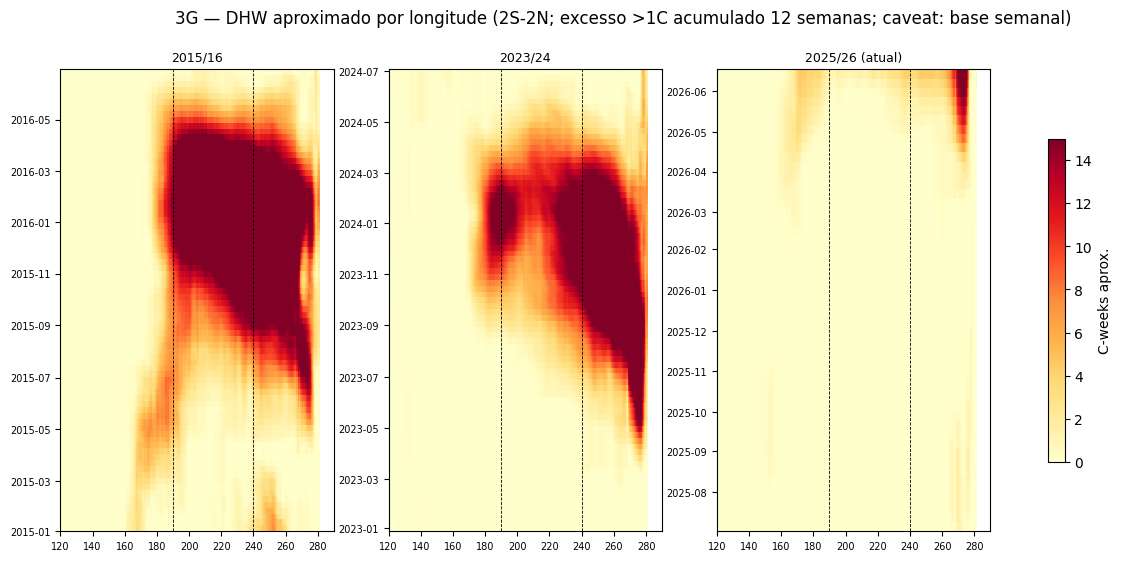

In [4]:
# Mapa 3G-1: DHW aproximado (semanal) por longitude — eventos recentes e janela atual
eq = u.load_eqband_weekly()
excesso = (eq - 1.0).clip(lower=0)
dhw_lon = excesso.rolling(12, min_periods=12).sum()
windows = [('2015-01-04','2016-06-26','2015/16'), ('2023-01-01','2024-06-30','2023/24'), ('2025-07-01', None, '2025/26 (atual)')]
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
lon = eq.columns.values
for ax, (t0, t1, ttl) in zip(axes, windows):
    seg = dhw_lon.loc[t0:t1] if t1 else dhw_lon.loc[t0:]
    pc = ax.pcolormesh(lon, seg.index, seg.values, cmap='YlOrRd', vmin=0, vmax=15, shading='auto')
    ax.axvline(190, color='k', ls='--', lw=0.6); ax.axvline(240, color='k', ls='--', lw=0.6)
    ax.set_title(ttl, fontsize=9); ax.tick_params(labelsize=7)
fig.suptitle('3G — DHW aproximado por longitude (2S-2N; excesso >1C acumulado 12 semanas; caveat: base semanal)')
fig.colorbar(pc, ax=axes, label='C-weeks aprox.', shrink=0.7)
u.save_fig(fig, 'phase3G_mapa_dhw_lon.png')
atual = dhw_lon.loc['2026-06-01':].max().max()
u.save_table(pd.DataFrame([{'dhw_lon_max_atual_cweeks': round(float(atual),2)}]), 'phase3G_estado_atual.csv', index=False)
print('DHW-lon maximo na janela atual (jun/2026):', round(float(atual),2), 'C-weeks aprox.')
plt.show()

**Leitura do 3G.** O composto duplo responde a pergunta isolada: o DHW **integra** o ciclo de vida — cresce durante o onset, atinge o máximo *depois* do pico da SSTA (defasagem positiva medida no composto e por evento) e decai lentamente, funcionando como memória do estresse térmico acumulado, não como precursor instantâneo. O escalonamento mostra que o DHW máximo separa as classes de evento (super≫strong≫weak), agregando a dimensão *duração* que a SSTA de pico sozinha não captura — dois eventos com o mesmo pico podem acumular calores muito diferentes. Combinado ao 3F (parcial significativa em +4 semanas), o veredito é: **DHW entra no parecer como métrica de severidade acumulada do evento e memória curta, não como precursor de longo lead.** A janela 2025/26 já apresenta acúmulo relevante na caixa Niño 3.4.